In [1]:
import math
import gymnasium as gym
from gymnasium import spaces
from typing import Dict
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import A2C, SAC
from gym.wrappers import FlattenObservation
from typing import Tuple, Dict, Optional, Any
import matplotlib.pyplot as plt
from stable_baselines3.common.utils import get_linear_fn
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
import numpy as np
import random
from scipy.optimize import brentq
import torch
import torch.nn as nn
import torch.optim as optim
from stable_baselines3 import SAC

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def solve_kyle_model_mine(N: int, sigma2_v: float, sigma2_u: float):
    """
    Calculates the multi-period Kyle model equilibrium using a two-pass algorithm.

    Args:
        N (int): The total number of trading periods.
        sigma2_v (float): The initial variance of the asset's value (Sigma_0).
        sigma2_u (float): The variance of the noise trader's orders.

    Returns:
        dict: A dictionary containing the numpy arrays for each equilibrium
              parameter sequence: 'Sigma', 'Lambda', 'Beta', and 'Alpha'.
    """
    # Helper for readability
    sigma_u = np.sqrt(sigma2_u)

    # --- ⏪ PASS 1: BACKWARD ITERATION for h_n ---
    # h_n = Sigma_n / Sigma_{n-1}
    h = np.zeros(N)
    h[-1] = 0.5  # Terminal condition for the last period (n=N)

    # Iterate backwards from n = N-1 down to n=1
    for n in reversed(range(N - 1)):
        # Calculate theta_{n+1} from the known h_{n+1}
        h_next = h[n + 1]
        theta_next = np.sqrt(h_next / (1 - h_next))

        # Define the function whose root h_n we need to find
        # f(h_n) = theta_{n+1} - (2*h_n - 1) / (h_n * sqrt(1-h_n)) = 0
        def root_func(h_n):
            if h_n <= 0.5 or h_n >= 1.0: # Numerical stability
                return np.inf
            return theta_next - (2 * h_n - 1) / (h_n * np.sqrt(1 - h_n))

        # Find the root h_n in the interval (0.5, 1.0)
        # brentq is a robust and efficient choice here.
        h[n] = brentq(root_func, 0.5 + 1e-9, 1.0 - 1e-9)

    # --- ⏩ PASS 2: FORWARD ITERATION for equilibrium parameters ---
    Sigma = np.zeros(N + 1)
    Lambda = np.zeros(N)
    Beta = np.zeros(N)
    Alpha = np.zeros(N)

    Sigma[0] = sigma2_v # Initial condition

    # Iterate forward from n=1 to N
    for n in range(N):
        # Update variance using the pre-calculated h_n
        Sigma[n + 1] = h[n] * Sigma[n]

        # Calculate the equilibrium parameters for period n
        Lambda[n] = np.sqrt((1 - h[n]) * Sigma[n + 1]) / sigma_u
        Beta[n] = (np.sqrt(1 - h[n]) * sigma_u) / np.sqrt(Sigma[n + 1])
        Alpha[n] = (sigma_u / (2 * np.sqrt(Sigma[n]))) * np.sqrt(h[n] / (1 - h[n]))
    
    return Beta, Lambda

In [3]:
def equilibrium_insider_action(v, mean_v, beta):
    return beta * (v - mean_v)

def equilibrium_market_maker_action(y, mean_v, lambda_):
    return mean_v + lambda_ * y

In [4]:
def evaluate_agent_actions_multiperiod_mm(model, env, action_scaling=5):
    obs, info = env.reset()

    steps = env.T
    optimal_insider_actions = np.zeros((steps))
    optimal_market_maker_actions = np.zeros((steps))

    trained_insider_actions = np.zeros((steps))
    trained_market_maker_actions = np.zeros((steps))

    values = np.linspace(1, steps, steps)

    p0 = env.p0
    v = env.v

    beta, lmbd = solve_kyle_model_mine(steps, env.sigma_v, env.sigma_u)

    total_reward_model = np.zeros((steps))
    total_reward_optimal = np.zeros((steps))

        

    for i in range(len(values)):
        
        trained_insider_actions[i] = equilibrium_insider_action(v, env.p, beta[i])
        optimal_insider_actions[i] = equilibrium_insider_action(v, p0, beta[i])
        u = env.u
        y = optimal_insider_actions[i] + u
        

        action, _ = model.predict(obs, deterministic=True)
        trained_market_maker_actions[i] = action * action_scaling
        optimal_market_maker_actions[i] = equilibrium_market_maker_action(y, p0, lmbd[i])
        p0 = lmbd[i] * y + p0
        obs, reward, terminated, truncated, info = env.step(action)

        

    env.reset()

    # plot: 2 subplots. one for insider (values vs action) and one for market maker (order vs action)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Insider subplot
    ax1.plot(values, optimal_insider_actions, label="Optimal", linestyle='--')
    ax1.plot(values, trained_insider_actions, label="Trained", linestyle='-')
    ax1.axvline(x=env.p0, color='black', linestyle=':', alpha=0.5)
    ax1.axhline(y=0, color='black', linestyle=':', alpha=0.5)
    ax1.set_title("Insider Action")
    ax1.set_xlabel("Timestep t")
    ax1.set_ylabel("Action x")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Market Maker subplot
    ax2.plot(values, optimal_market_maker_actions, label="Optimal", linestyle='--')
    ax2.plot(values, trained_market_maker_actions, label="Trained", linestyle='-')
    ax2.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    ax2.axhline(y=env.p0, color='black', linestyle=':', alpha=0.5)
    ax2.set_title("Market Maker Action")
    ax2.set_xlabel("Timestep t")
    ax2.set_ylabel("Price p")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() 


In [5]:
def evaluate_agent_actions_multiperiod(model, env, n_stdevs, action_scaling=5):
    obs, info = env.reset()

    steps = env.T
    optimal_insider_actions = np.zeros((steps))
    optimal_market_maker_actions = np.zeros((steps))

    trained_insider_actions = np.zeros((steps))
    trained_market_maker_actions = np.zeros((steps))

    values = np.linspace(1, steps, steps)
    beta, lmbd = solve_kyle_model_mine(steps, env.sigma_v, env.sigma_u)

    p0 = env.p0
    v = env.v

    total_reward_model = np.zeros((steps))
    total_reward_optimal = np.zeros((steps))

        

    for i in range(len(values)):
        
        action, _ = model.predict(obs, deterministic=True) 
        obs, reward, terminated, truncated, info = env.step(action)
        trained_insider_actions[i] = action * action_scaling 
        optimal_insider_actions[i] = equilibrium_insider_action(v, p0, beta[i])
        u = env.u
        y = optimal_insider_actions[i] + u
        total_reward_model[i] = reward
        

        trained_market_maker_actions[i] = env.p
        optimal_market_maker_actions[i] = equilibrium_market_maker_action(y, p0, lmbd[i])
        p0 = lmbd[i] * y + p0
        total_reward_optimal[i] = (v - optimal_market_maker_actions[i]) * optimal_insider_actions[i]

        

    env.reset()

    # plot: 2 subplots. one for insider (values vs action) and one for market maker (order vs action)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Insider subplot
    ax1.plot(values, optimal_insider_actions, label="Optimal", linestyle='--')
    ax1.plot(values, trained_insider_actions, label="Trained", linestyle='-')
    ax1.axvline(x=env.p0, color='black', linestyle=':', alpha=0.5)
    ax1.axhline(y=0, color='black', linestyle=':', alpha=0.5)
    ax1.set_title("Insider Action")
    ax1.set_xlabel("Timestep t")
    ax1.set_ylabel("Action x")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Market Maker subplot
    ax2.plot(values, optimal_market_maker_actions, label="Optimal", linestyle='--')
    ax2.plot(values, trained_market_maker_actions, label="Trained", linestyle='-')
    ax2.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    ax2.axhline(y=env.p0, color='black', linestyle=':', alpha=0.5)
    ax2.set_title("Market Maker Action")
    ax2.set_xlabel("Timestep t")
    ax2.set_ylabel("Price p")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

        # Insider Reward subplot
    ax3.plot(values, total_reward_optimal, label="Optimal", linestyle='--')
    ax3.plot(values, total_reward_model, label="Trained", linestyle='-')
    ax3.axvline(x=env.p0, color='black', linestyle=':', alpha=0.5)
    ax3.axhline(y=0, color='black', linestyle=':', alpha=0.5)
    ax3.set_title("Insider Action")
    ax3.set_xlabel("Timestep t")
    ax3.set_ylabel("Action x")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.show() 

    return total_reward_model, total_reward_optimal


In [104]:
from environments import KyleModelEnvInsider


# Example usage with Gym interface
print("Testing Kyle model with Gym interface")

env_insider = KyleModelEnvInsider()

# Initialize the model

clip_range_schedule = get_linear_fn(start=0.4, end=0.2, end_fraction=0.8)

policy_kwargs = dict(
    net_arch=dict(pi=[128,128], vf=[128,128])  # Separate networks
)

model_insider = PPO(
    "MultiInputPolicy",
    env_insider,
    verbose = 1,
    learning_rate = 0.0004,
    clip_range = clip_range_schedule,
    policy_kwargs=policy_kwargs

)


Testing Kyle model with Gym interface
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [105]:
action_scaling = 5
plots_number = 1

In [106]:
#model_insider.learn(total_timesteps = 85_000)
#model_insider.save("ppo_kyle_insider_nohistory")
model_insider = PPO.load("ppo_kyle_insider_nohistory", env=env_insider)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\2199990385.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_insider_actions[i] = action * action_scaling


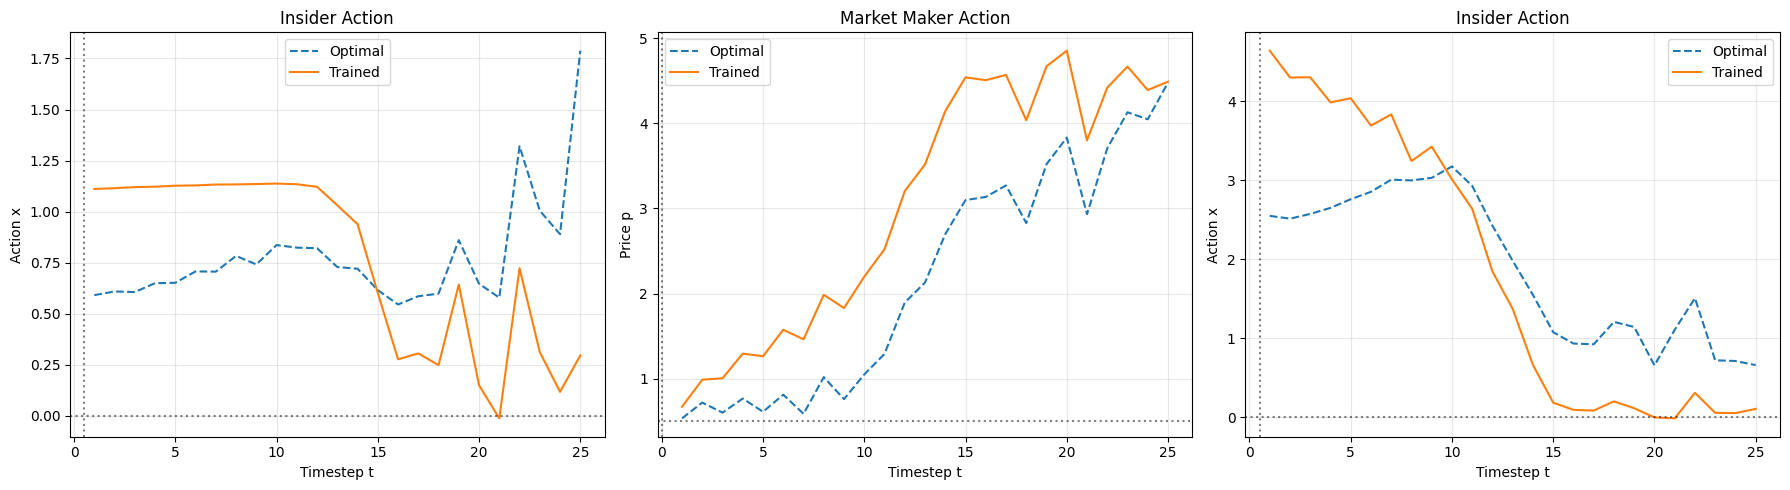

In [116]:
for _ in range(plots_number):
    trm, tro = evaluate_agent_actions_multiperiod(model_insider, env_insider, n_stdevs=3, action_scaling=action_scaling)

In [117]:
model_insider = SAC(
    policy="MultiInputPolicy",
    env=env_insider,
    verbose = 1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [55]:
#model_insider.learn(total_timesteps = 6_000)
#model_insider.save("sac_kyle_insider_nohistory")

In [118]:
model_insider = SAC.load("sac_kyle_insider_nohistory", env=env_insider)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\2199990385.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_insider_actions[i] = action * action_scaling


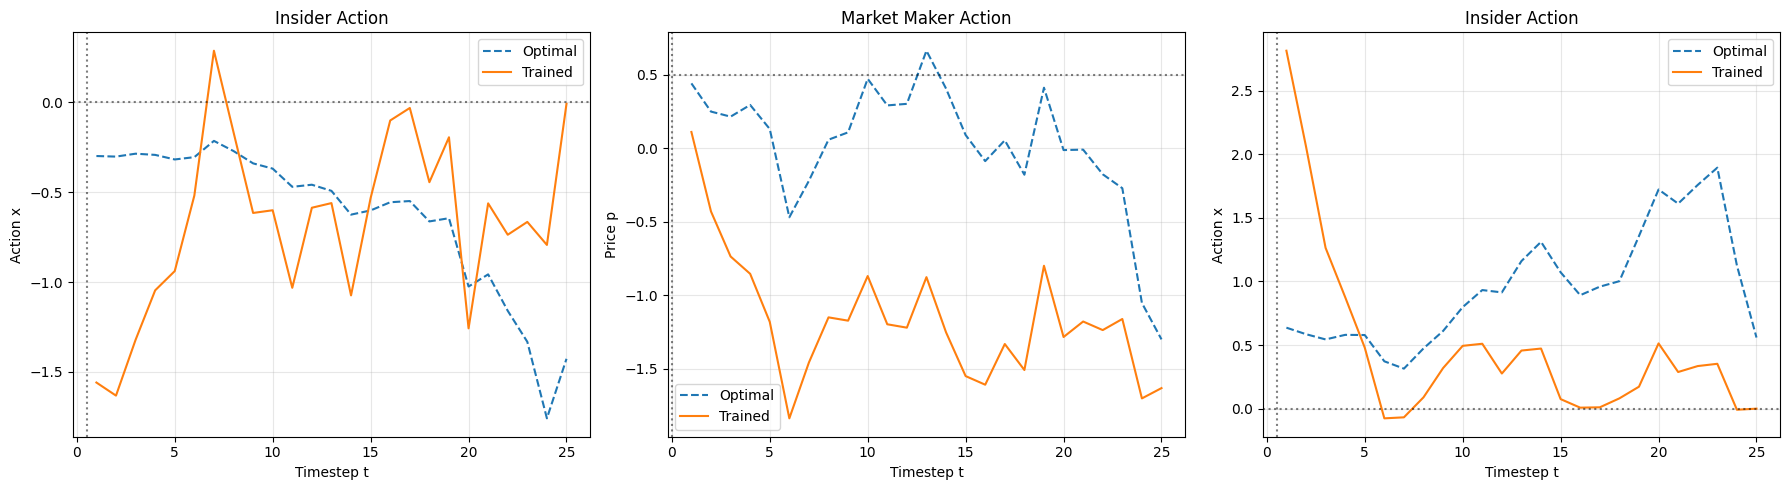

In [126]:
for _ in range(plots_number):
    trm, tro = evaluate_agent_actions_multiperiod(model_insider, env_insider, n_stdevs=3, action_scaling=action_scaling)

In [127]:
from environments import KyleModelEnvInsiderHistoryPrice


# Example usage with Gym interface
print("Testing Kyle model with Gym interface")

env_insider = KyleModelEnvInsiderHistoryPrice()

# Initialize the model

clip_range_schedule = get_linear_fn(start=0.4, end=0.2, end_fraction=0.8)

policy_kwargs = dict(
    net_arch=dict(pi=[128,128], vf=[128,128])  # Separate networks
)

model_insider = PPO(
    "MultiInputPolicy",
    env_insider,
    verbose = 1,
    learning_rate = 0.0004,
    clip_range = clip_range_schedule,
    policy_kwargs=policy_kwargs
)

Testing Kyle model with Gym interface
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [59]:
# model_insider.learn(total_timesteps = 85_000)
# model_insider.save("ppo_kyle_insider_history")

In [128]:
model_insider = PPO.load("ppo_kyle_insider_history", env=env_insider)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\2199990385.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_insider_actions[i] = action * action_scaling


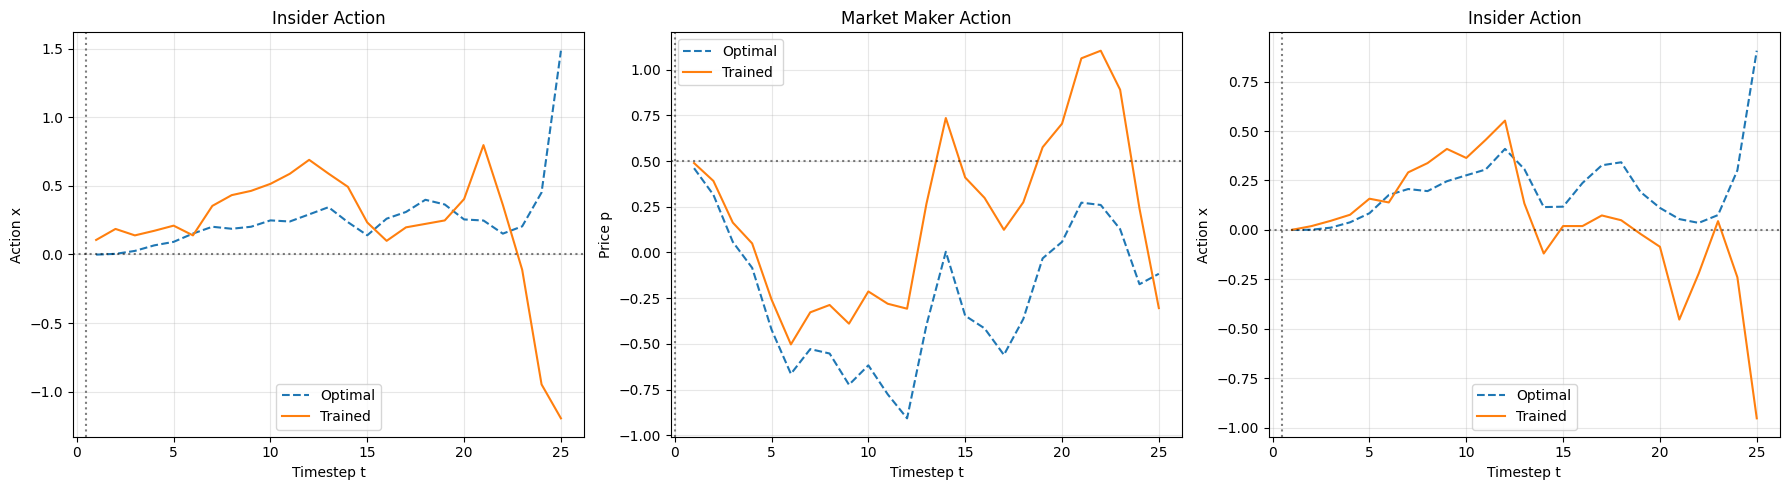

In [139]:
for _ in range(plots_number):
    trm, tro = evaluate_agent_actions_multiperiod(model_insider, env_insider, n_stdevs=3, action_scaling=action_scaling)

In [62]:
model_insider = SAC(
    policy="MultiInputPolicy",
    env=env_insider,
    verbose = 1
)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [63]:
#model_insider.learn(total_timesteps = 6_000)
#model_insider.save("sac_kyle_insider_history")

In [64]:
model_insider = SAC.load("sac_kyle_insider_history", env=env_insider)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\2199990385.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_insider_actions[i] = action * action_scaling


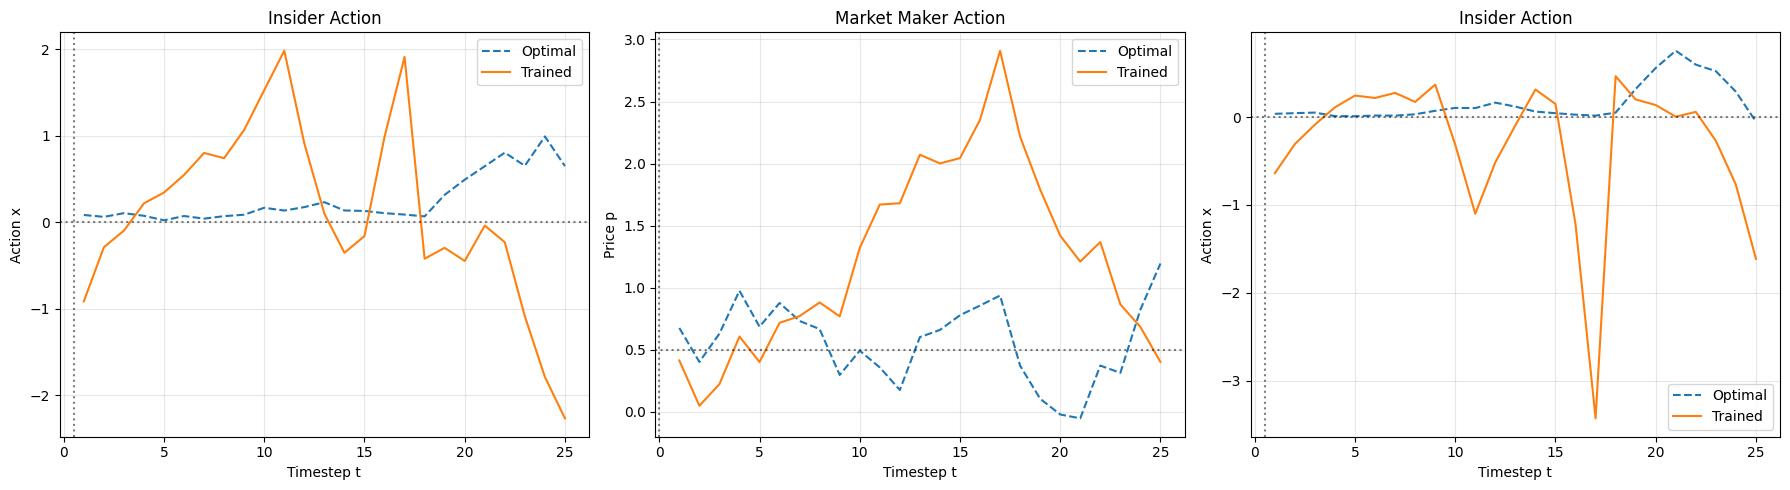

In [65]:
for _ in range(plots_number):
    trm, tro = evaluate_agent_actions_multiperiod(model_insider, env_insider, n_stdevs=3, action_scaling=action_scaling)

In [66]:
from environments import KyleModelEnvMM

# Example usage with Gym interface
print("Testing Kyle model with Gym interface")

env_mm = KyleModelEnvMM()

# Initialize the model

clip_range_schedule = get_linear_fn(start=0.3, end=0.2, end_fraction=0.9)




policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])  # Separate networks
)


model_mm = SAC(
    "MultiInputPolicy",
    env_mm,
    verbose = 1
)

#model_mm.learn(total_timesteps = 5_000)
#model_mm.save("sac_kyle_mm_nohistory")

model_mm = SAC.load("sac_kyle_mm_nohistory", env=env_mm)

Testing Kyle model with Gym interface
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\3121896030.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_market_maker_actions[i] = action * action_scaling


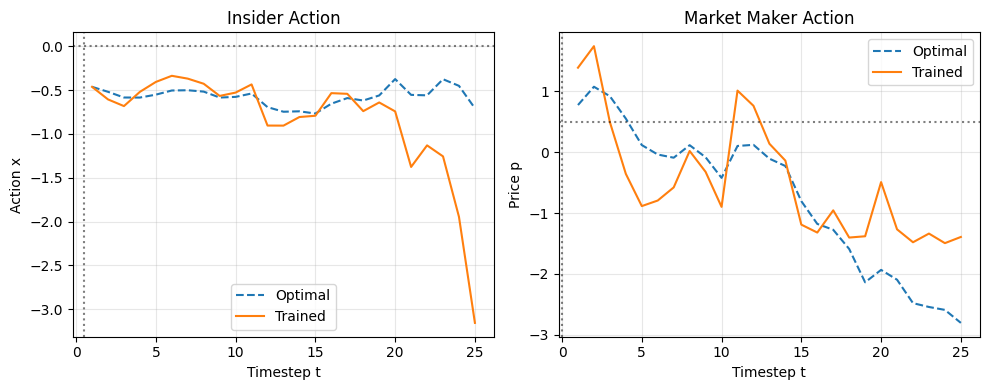

In [67]:
for _ in range(plots_number):
    evaluate_agent_actions_multiperiod_mm(model_mm, env_mm)

In [68]:
model_mm = PPO(
    "MultiInputPolicy",
    env_mm,
    verbose = 1,
    learning_rate = 0.0004,
    clip_range = clip_range_schedule,
    policy_kwargs=policy_kwargs
)

#model_mm.learn(total_timesteps = 150_000)
#model_mm.save("ppo_kyle_mm_nohistory")

model_mm = PPO.load("ppo_kyle_mm_nohistory", env=env_mm)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\krist\AppData\Local\Temp\ipykernel_14820\3121896030.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trained_market_maker_actions[i] = action * action_scaling


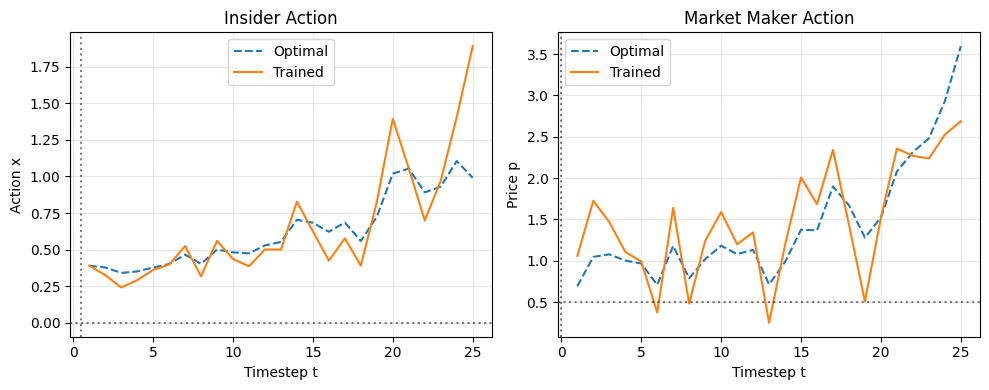

In [152]:
for _ in range(plots_number):
    evaluate_agent_actions_multiperiod_mm(model_mm, env_mm)